# 3D Object Reconstruction with SAM-3D-Objects and OpenVINO

[SAM-3D-Objects](https://github.com/facebookresearch/sam-3d-objects) is Meta's state-of-the-art pipeline for lifting 2D images into 3D Gaussian Splats. Given a single image and an object mask, the pipeline reconstructs a full 3D representation of the object through a two-stage process:

1. **Stage 1 — Sparse Structure Generation**: DINOv2 condition embeddings drive a flow-matching transformer (SS Generator) to predict a sparse 3D occupancy grid, decoded by the SS Decoder into voxel coordinates.
2. **Stage 2 — Structured Latent Generation**: A second flow-matching transformer (SLat Generator) produces per-voxel latent features, which SLat Decoders convert into 3D Gaussian Splat parameters (position, opacity, scale, rotation, color).

The pipeline also uses **MoGe** (Monocular Geometry Estimation) for depth/point-map prediction and **PointPatchEmbed** for fusing geometric information with visual features.

In this notebook, we demonstrate how to:
- Download the SAM-3D-Objects model from ModelScope
- Convert all weighted sub-models to OpenVINO IR format
- Run single-object and multi-object 3D reconstruction with OpenVINO acceleration
- Optimize models using NNCF post-training quantization
- Build an interactive Gradio demo

#### Table of contents:

- [Prerequisites](#Prerequisites)
- [Download Model and Configure Pipeline](#Download-Model-and-Configure-Pipeline)
- [Convert SAM-3D Models to OpenVINO IR Format](#Convert-SAM-3D-Models-to-OpenVINO-IR-Format)
- [Select Inference Device](#Select-Inference-Device)
- [Verify Conversion Accuracy](#Verify-Conversion-Accuracy)
- [Create OpenVINO Pipeline](#Create-OpenVINO-Pipeline)
- [Single Object 3D Reconstruction](#Single-Object-3D-Reconstruction)
- [Multi Object 3D Reconstruction](#Multi-Object-3D-Reconstruction)
- [Optimize with NNCF Quantization](#Optimize-with-NNCF-Quantization)
- [Interactive Gradio Demo](#Interactive-Gradio-Demo)

## Prerequisites
[back to top ⬆️](#Table-of-contents:)

In [2]:
# Fetch `notebook_utils` module
import requests
from pathlib import Path

if not Path("notebook_utils.py").exists():
    r = requests.get(
        url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/notebook_utils.py",
    )
    open("notebook_utils.py", "w").write(r.text)

if not Path("cmd_helper.py").exists():
    r = requests.get(
        url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/cmd_helper.py",
    )
    open("cmd_helper.py", "w").write(r.text)

if not Path("pip_helper.py").exists():
    r = requests.get(
        url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/pip_helper.py",
    )
    open("pip_helper.py", "w").write(r.text)

# Read more about telemetry collection at https://github.com/openvinotoolkit/openvino_notebooks?tab=readme-ov-file#-telemetry
from notebook_utils import collect_telemetry

collect_telemetry("sam-3d-objects-reconstruction.ipynb")

In [3]:
import subprocess, sys

def pip_install_safe(*args):
    """Install packages, don't fail if already installed or build issues."""
    cli_args = []
    for arg in args:
        cli_args.extend(str(arg).split(" "))
    result = subprocess.run(
        [sys.executable, "-m", "pip", "install", *cli_args],
        capture_output=True, text=True,
    )
    if result.returncode != 0:
        print(f"WARNING: pip install failed for some packages:\n{result.stderr[-500:]}")
    return result.returncode

# Core dependencies (PyPI packages — reliable install)
pip_install_safe(
    "-q",
    "openvino>=2026.0.0",
    "nncf>=2.13",
    "gradio>=4.13",
    "torch",
    "torchvision",
    "numpy",
    "Pillow",
    "matplotlib",
    "omegaconf",
    "hydra-core",
    "trimesh",
    "imageio",
    "scipy",
    "einops",
    "roma",
    "rootutils",
    "astor",
    "easydict",
    "lightning",
    "plyfile",
    "pyvista",
    "scikit-image",
    "opencv-python",
    "igraph",
    "loguru",
    "open3d",
    "optree",
    "timm",
    "seaborn",
    "xatlas",
    "pymeshfix",
    "huggingface_hub",
    "modelscope",
)

# Git dependencies — install separately (may need git + C compiler)
for git_dep in [
    "git+https://github.com/EasternJournalist/utils3d.git",
    "git+https://github.com/microsoft/MoGe.git",
]:
    try:
        pkg_name = git_dep.split("/")[-1].replace(".git", "")
        __import__(pkg_name.replace("-", "_").lower())
        print(f"  {pkg_name} already installed, skipping")
    except ImportError:
        print(f"  Installing {pkg_name} from git …")
        pip_install_safe("-q", git_dep)

# Verify critical packages
import openvino, torch, moge, utils3d
print(f"openvino={openvino.__version__}, torch={torch.__version__}, moge installed ✓, utils3d installed ✓")

  utils3d already installed, skipping
  MoGe already installed, skipping
openvino=2026.0.0-20965-c6d6a13a886-releases/2026/0, torch=2.8.0+cpu, moge installed ✓, utils3d installed ✓


In [4]:
import os
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import torch

NOTEBOOK_DIR = Path.cwd()

# ---------------------------------------------------------------------------
# Download SAM-3D-Objects model weights from ModelScope
# ---------------------------------------------------------------------------
from modelscope import snapshot_download

MODEL_CACHE_DIR = NOTEBOOK_DIR / "models"
LOCAL_MODEL_DIR = MODEL_CACHE_DIR / "facebook" / "sam-3d-objects"

if (LOCAL_MODEL_DIR / "checkpoints" / "pipeline.yaml").exists():
    SAM3D_MODEL_ROOT = LOCAL_MODEL_DIR
    print(f"Model already exists, skip download: {SAM3D_MODEL_ROOT}")
else:
    SAM3D_MODEL_ROOT = Path(
        snapshot_download(
            "facebook/sam-3d-objects",
            cache_dir=str(MODEL_CACHE_DIR),
        )
    )
print(f"Model downloaded to: {SAM3D_MODEL_ROOT}")

# ---------------------------------------------------------------------------
# Clone SAM-3D-Objects source code (inference pipeline)
# ---------------------------------------------------------------------------
SAM3D_ROOT = NOTEBOOK_DIR / "sam-3d-objects"
if not (SAM3D_ROOT / "sam3d_objects").exists():
    import subprocess
    subprocess.run(
        ["git", "clone", "--depth", "1", "https://github.com/facebookresearch/sam-3d-objects.git", str(SAM3D_ROOT)],
        check=True,
    )
    print(f"Cloned sam-3d-objects repo to: {SAM3D_ROOT}")
else:
    print(f"sam-3d-objects repo already exists at: {SAM3D_ROOT}")

SAM3D_NOTEBOOK = SAM3D_ROOT / "notebook"

for p in [str(SAM3D_ROOT), str(SAM3D_NOTEBOOK), str(NOTEBOOK_DIR)]:
    if p not in sys.path:
        sys.path.insert(0, p)

# Set environment variables BEFORE any sam3d_objects imports
os.environ.setdefault("CONDA_PREFIX", "/usr")
os.environ.setdefault("CUDA_HOME", "/usr")

# Change working directory so Hydra relative paths work
os.chdir(str(SAM3D_ROOT))

print(f"SAM-3D-Objects root: {SAM3D_ROOT}")
print(f"Model checkpoints:   {SAM3D_MODEL_ROOT}")
print(f"Notebook directory:  {NOTEBOOK_DIR}")
print(f"PyTorch version:     {torch.__version__}")
print(f"CUDA available:      {torch.cuda.is_available()}")

Model already exists, skip download: /home/ethan/intel/openvino_notebooks/notebooks/sam-3d-objects-reconstruction/models/facebook/sam-3d-objects
Model downloaded to: /home/ethan/intel/openvino_notebooks/notebooks/sam-3d-objects-reconstruction/models/facebook/sam-3d-objects
sam-3d-objects repo already exists at: /home/ethan/intel/openvino_notebooks/notebooks/sam-3d-objects-reconstruction/sam-3d-objects
SAM-3D-Objects root: /home/ethan/intel/openvino_notebooks/notebooks/sam-3d-objects-reconstruction/sam-3d-objects
Model checkpoints:   /home/ethan/intel/openvino_notebooks/notebooks/sam-3d-objects-reconstruction/models/facebook/sam-3d-objects
Notebook directory:  /home/ethan/intel/openvino_notebooks/notebooks/sam-3d-objects-reconstruction
PyTorch version:     2.8.0+cpu
CUDA available:      False


In [5]:
# Apply CUDA patches — this MUST happen before any sam3d_objects import.
# The helper mocks CUDA-only packages (pytorch3d, spconv, kaolin) and patches
# the pipeline to run on CPU.
import sam_3d_objects_helper as helper

helper.patch_cuda_for_cpu()

2026-03-23 18:15:04.197 | INFO     | sam3d_objects.pipeline.inference_pipeline:set_attention_backend:17 - GPU name is CPU


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


2026-03-23 18:15:06.438 | INFO     | sam3d_objects.model.backbone.tdfy_dit.modules.sparse:__from_env:39 - [SPARSE] Backend: spconv, Attention: sdpa
2026-03-23 18:15:06.443 | INFO     | sam3d_objects.model.backbone.tdfy_dit.modules.attention:__from_env:30 - [ATTENTION] Using backend: sdpa


[SPARSE][CONV] spconv algo: auto


2026-03-23 18:15:07.842 | WARNING  | sam3d_objects.data.dataset.tdfy.preprocessor:__post_init__:51 - No rgb pointmap normalizer provided, using scale + shift 
2026-03-23 18:15:07.843 | WARNING  | sam3d_objects.data.dataset.tdfy.preprocessor:__post_init__:51 - No rgb pointmap normalizer provided, using scale + shift 


[OV-SAM3D] CUDA patches applied — running on CPU / OpenVINO


## Download Model and Configure Pipeline
[back to top ⬆️](#Table-of-contents:)

The SAM-3D-Objects pipeline is configured via a Hydra YAML config (`pipeline.yaml`) that specifies:
- **Condition embedders**: DINOv2 ViT-L/14 backbones for image and mask encoding
- **SS Generator**: 24-block MOT (Multi-Object Transformer) for sparse structure flow matching
- **SS Decoder**: 3D convolutional VAE decoder (latent → occupancy grid)
- **SLat Generator**: 24-block sparse transformer for structured latent flow matching
- **SLat Decoders**: Transformer-based decoders for Gaussian splat parameters
- **MoGe**: ViT-based monocular geometry estimator for point-map prediction

We load the config, patch it for CPU inference, and instantiate the full pipeline.

In [6]:
from omegaconf import OmegaConf
from hydra.utils import instantiate

CONFIG_PATH = SAM3D_MODEL_ROOT / "checkpoints" / "pipeline.yaml"
assert CONFIG_PATH.exists(), f"pipeline.yaml not found at {CONFIG_PATH}"

# Load and patch the pipeline config for CPU inference
config = OmegaConf.load(str(CONFIG_PATH))
config = helper.patch_pipeline_config(config)
config.workspace_dir = str(CONFIG_PATH.parent)

print("Pipeline configuration:")
print(f"  Device:           {config.device}")
print(f"  Dtype:            {config.dtype}")
print(f"  Decode formats:   {config.decode_formats}")
print(f"  Rendering engine: {config.rendering_engine}")

Pipeline configuration:
  Device:           cpu
  Dtype:            float32
  Decode formats:   ['gaussian', 'mesh']
  Rendering engine: pytorch3d


In [7]:
# Instantiate the full pipeline on CPU
# This loads all model weights (DINOv2, SS Generator, SLat Generator, decoders, MoGe)
print("Instantiating SAM-3D-Objects pipeline on CPU …")
t0 = time.time()

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pipeline = instantiate(config)

t1 = time.time()
print(f"Pipeline loaded in {t1 - t0:.1f}s on device: {pipeline.device}")

# Print model summary
print(f"\nLoaded models:")
for name in pipeline.models:
    model = pipeline.models[name]
    n_params = sum(p.numel() for p in model.parameters()) if hasattr(model, "parameters") else 0
    print(f"  {name:30s}  {n_params / 1e6:>8.2f}M params")

print(f"\nCondition embedders:")
for name in pipeline.condition_embedders:
    print(f"  {name}")

2026-03-23 18:15:07.990 | WARNING  | sam3d_objects.data.dataset.tdfy.preprocessor:__post_init__:51 - No rgb pointmap normalizer provided, using scale + shift 
2026-03-23 18:15:07.995 | WARNING  | sam3d_objects.data.dataset.tdfy.preprocessor:__post_init__:51 - No rgb pointmap normalizer provided, using scale + shift 
2026-03-23 18:15:07.998 | INFO     | sam3d_objects.pipeline.inference_pipeline:__init__:100 - self.device: cpu
2026-03-23 18:15:07.999 | INFO     | sam3d_objects.pipeline.inference_pipeline:__init__:101 - CUDA_VISIBLE_DEVICES: None
2026-03-23 18:15:08.000 | INFO     | sam3d_objects.pipeline.inference_pipeline:__init__:102 - Actually using GPU: cpu(mock)
2026-03-23 18:15:08.000 | INFO     | sam3d_objects.pipeline.inference_pipeline:init_pose_decoder:297 - Using pose decoder: ScaleShiftInvariant
2026-03-23 18:15:08.001 | INFO     | sam3d_objects.pipeline.inference_pipeline:__init__:133 - Loading model weights...


Instantiating SAM-3D-Objects pipeline on CPU …


2026-03-23 18:15:16.505 | INFO     | sam3d_objects.model.io:load_model_from_checkpoint:158 - Loading checkpoint from /home/ethan/intel/openvino_notebooks/notebooks/sam-3d-objects-reconstruction/models/facebook/sam-3d-objects/checkpoints/ss_generator.ckpt
2026-03-23 18:15:24.332 | INFO     | sam3d_objects.model.io:load_model_from_checkpoint:158 - Loading checkpoint from /home/ethan/intel/openvino_notebooks/notebooks/sam-3d-objects-reconstruction/models/facebook/sam-3d-objects/checkpoints/slat_generator.ckpt
2026-03-23 18:15:26.548 | INFO     | sam3d_objects.model.io:load_model_from_checkpoint:158 - Loading checkpoint from /home/ethan/intel/openvino_notebooks/notebooks/sam-3d-objects-reconstruction/models/facebook/sam-3d-objects/checkpoints/ss_decoder.ckpt
2026-03-23 18:15:27.277 | INFO     | sam3d_objects.model.io:load_model_from_checkpoint:158 - Loading checkpoint from /home/ethan/intel/openvino_notebooks/notebooks/sam-3d-objects-reconstruction/models/facebook/sam-3d-objects/checkpoint

Pipeline loaded in 41.7s on device: cpu

Loaded models:
  ss_generator                      959.96M params
  slat_generator                    600.43M params
  ss_encoder                          0.00M params
  ss_decoder                         73.67M params
  slat_decoder_gs                    85.37M params
  slat_decoder_gs_4                  85.07M params
  slat_decoder_mesh                  90.93M params

Condition embedders:
  ss_condition_embedder
  slat_condition_embedder


## Convert SAM-3D Models to OpenVINO IR Format
[back to top ⬆️](#Table-of-contents:)

Now we convert all weighted sub-models in the pipeline to OpenVINO Intermediate Representation (IR) format. The conversion process:

1. **Wraps** each PyTorch module in a clean `nn.Module` designed for static-graph export (no dynamic control flow, no `SparseTensor`)
2. **Converts** using `ov.convert_model()` with example inputs
3. **Saves** the IR files (`.xml` + `.bin`) to disk

The following models are converted:

| Model | Architecture | Purpose |
|-------|-------------|--------|
| DINOv2 Backbone (merged) | ViT-L/14 (2 outputs) | Shared image/mask condition encoding for SS & SLat stages |
| PointPatchEmbed Inner | Windowed Attention + Pos Embed | Pointmap geometric feature extraction |
| SS Decoder | 3D ConvNet | Latent volume → occupancy grid |
| SS Generator | 24-block MOT Transformer | Sparse structure flow matching backbone |
| SLat Generator Full | U-Net + 24-block Sparse Transformer | Full structured latent flow matching backbone |
| SLat Decoders (GS/GS-4) | 12-block Sparse Transformer | Per-voxel Gaussian splat parameter prediction |
| SLat Mesh Decoder (merged) | 12-block Transformer + Upsample | Per-voxel mesh features |
| MoGe Depth Model | DINOv2 ViT-L + Regression Head | Monocular depth/point-map estimation |
| Embedder Projections | LayerNorm + FFN | Per-embedder feature projection |

**Weight coverage**: ~100% of all model weights are converted to OV IR.

In [8]:
OV_MODEL_DIR = NOTEBOOK_DIR / "ov_models"
OV_MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Convert all sub-models to OpenVINO IR

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    compiled_models = helper.convert_all_models(pipeline, OV_MODEL_DIR)

print(f"Converted {len(compiled_models)} models")

# List saved IR files
print(f"\nSaved IR files in {OV_MODEL_DIR}:")
for f in sorted(OV_MODEL_DIR.glob("*.xml")):
    bin_file = f.with_suffix(".bin")
    bin_size = bin_file.stat().st_size / (1024 * 1024) if bin_file.exists() else 0
    print(f"  {f.name:40s}  {bin_size:>8.1f} MB")

[OV-SAM3D] Converting merged DINOv2 backbone (1 model for all 4 embedders) …
[OV-SAM3D] Skipping /home/ethan/intel/openvino_notebooks/notebooks/sam-3d-objects-reconstruction/ov_models/dino_backbone.xml — already exists
[OV-SAM3D] Converting PointPatchEmbed inner attention …
[OV-SAM3D] Skipping /home/ethan/intel/openvino_notebooks/notebooks/sam-3d-objects-reconstruction/ov_models/pointpatch_embed_inner.xml — already exists
[OV-SAM3D] Converting SS decoder …
[OV-SAM3D] Skipping /home/ethan/intel/openvino_notebooks/notebooks/sam-3d-objects-reconstruction/ov_models/ss_decoder.xml — already exists
[OV-SAM3D] Converting SS generator backbone …
[OV-SAM3D] Skipping /home/ethan/intel/openvino_notebooks/notebooks/sam-3d-objects-reconstruction/ov_models/ss_generator.xml — already exists
[OV-SAM3D] Converting SLat generator full backbone …
[OV-SAM3D] Skipping /home/ethan/intel/openvino_notebooks/notebooks/sam-3d-objects-reconstruction/ov_models/slat_generator_full.xml — already exists
[OV-SAM3D] C

## Select Inference Device
[back to top ⬆️](#Table-of-contents:)

Select the device to use for OpenVINO inference. The device will be used for both model compilation and inference. Available devices depend on your system configuration.

In [9]:
from notebook_utils import device_widget

device = device_widget("CPU", exclude=["NPU"])
device

Dropdown(description='Device:', options=('CPU', 'AUTO'), value='CPU')

## Verify Conversion Accuracy
[back to top ⬆️](#Table-of-contents:)

To ensure the OpenVINO conversion is numerically faithful, we compare the outputs of the original PyTorch models with their OpenVINO counterparts using synthetic inputs. We verify **all** converted models including the MoGe depth model.

Metrics:
- **Max absolute difference** — worst-case numerical error
- **Mean absolute difference** — average numerical error
- **Cosine similarity** — directional alignment of output vectors (1.0 = perfect)

In [10]:
import openvino as ov

core = ov.Core()
accuracy_results = []

# --- 1. Merged DINOv2 Backbone (both outputs) ---
print("=" * 60)
print("1. Merged DINOv2 Backbone (postnorm & prenorm outputs)")
print("=" * 60)
ss_emb = pipeline.condition_embedders["ss_condition_embedder"]
slat_emb = pipeline.condition_embedders["slat_condition_embedder"]

ov_model = core.read_model(str(OV_MODEL_DIR / "dino_backbone.xml"))
ov_compiled = core.compile_model(ov_model, device.value)

test_input = torch.randn(1, 3, 518, 518, dtype=torch.float32)
with torch.no_grad():
    pt_postnorm = ss_emb.embedder_list[0][0](test_input)
    pt_prenorm = slat_emb.embedder_list[0][0](test_input)

ov_result = ov_compiled(test_input.numpy())
ov_postnorm = torch.from_numpy(ov_result[0].copy())
ov_prenorm = torch.from_numpy(ov_result[1].copy())

ok1 = helper.compare_outputs(pt_postnorm, ov_postnorm, "DINOv2 postnorm (SS)", atol=0.02)
ok2 = helper.compare_outputs(pt_prenorm, ov_prenorm, "DINOv2 prenorm (SLat)", atol=0.02)
accuracy_results.append(("DINOv2 Backbone postnorm", ok1, pt_postnorm.shape))
accuracy_results.append(("DINOv2 Backbone prenorm", ok2, pt_prenorm.shape))

# --- 2. SS Decoder ---
print("\n" + "=" * 60)
print("2. SS Decoder (3D ConvNet)")
print("=" * 60)
ss_decoder = pipeline.models["ss_decoder"]

test_latent = torch.randn(1, 8, 16, 16, 16, dtype=torch.float32)
with torch.no_grad():
    pt_dec = ss_decoder(test_latent)

ov_dec_model = core.read_model(str(OV_MODEL_DIR / "ss_decoder.xml"))
ov_dec_compiled = core.compile_model(ov_dec_model, device.value)
ov_dec = torch.from_numpy(ov_dec_compiled(test_latent.numpy())[0].copy())
ok3 = helper.compare_outputs(pt_dec, ov_dec, "SS Decoder", atol=5e-3)
accuracy_results.append(("SS Decoder", ok3, pt_dec.shape))

# --- 3. SS Generator ---
print("\n" + "=" * 60)
print("3. SS Generator (24-block MOT Transformer)")
print("=" * 60)
ss_gen_backbone = helper._unwrap_to_backbone(pipeline.models["ss_generator"])
ss_gen_wrapper = helper.SSGeneratorForOV(ss_gen_backbone).eval().float()
ss_gen_wrapper.dtype = torch.float32

ov_ss_gen = core.compile_model(core.read_model(str(OV_MODEL_DIR / "ss_generator.xml")), device.value)
ov_ss_gen_call = helper.OVSSGenerator(ov_ss_gen)

B = 1
shape_lat = torch.randn(B, 4096, 8)
pose_examples = []
for name in ss_gen_wrapper._pose_names:
    lm = ss_gen_wrapper.latent_mapping[name]
    in_ch = lm.input_layer.in_features
    n_tok = lm.pos_emb.shape[0]
    pose_examples.append(torch.randn(B, n_tok, in_ch))

t_test = torch.zeros(B)
d_test = torch.zeros(B)
cond_test = torch.randn(B, 1370, 1024)

with torch.no_grad():
    pt_ss_out = ss_gen_wrapper(shape_lat, *pose_examples, t_test, d_test, cond_test)
    ov_ss_out = ov_ss_gen_call(shape_lat, *pose_examples, t_test, d_test, cond_test)

ok4 = helper.compare_outputs(pt_ss_out[0], ov_ss_out[0], "SS Generator (shape)", atol=0.01)
accuracy_results.append(("SS Generator", ok4, pt_ss_out[0].shape))

# --- 4. SLat Generator Full ---
print("\n" + "=" * 60)
print("4. SLat Generator Full (U-Net + 24 core blocks)")
print("=" * 60)
slat_gen_path = OV_MODEL_DIR / "slat_generator_full.xml"
if slat_gen_path.exists():
    slat_backbone = helper._unwrap_to_backbone(pipeline.models["slat_generator"])
    pt_wrapper = helper.SLatGeneratorFullForOV(slat_backbone).eval().float()
    pt_wrapper.dtype = torch.float32

    N_vox = 256
    test_feats = torch.randn(N_vox, 8)
    test_coords = torch.randint(0, 32, (N_vox, 3))
    test_t = torch.zeros(1)
    test_cond = torch.randn(1, 1370, 1024)

    with torch.no_grad():
        pt_slat = pt_wrapper(test_feats, test_coords, test_t, test_cond)

    ov_slat = core.compile_model(core.read_model(str(slat_gen_path)), device.value)
    ov_req = ov_slat.create_infer_request()
    ov_req.infer([test_feats.numpy(), test_coords.float().numpy(), test_t.numpy(), test_cond.numpy()])
    ov_slat_out = torch.from_numpy(ov_req.get_output_tensor(0).data.copy())

    ok5 = helper.compare_outputs(pt_slat, ov_slat_out, "SLat Generator Full", atol=0.01)
    accuracy_results.append(("SLat Generator Full", ok5, pt_slat.shape))
else:
    print("  [SKIP] slat_generator_full.xml not found")

# --- 5. SLat Decoders (GS, GS-4) ---
print("\n" + "=" * 60)
print("5. SLat Decoders (GS, GS-4)")
print("=" * 60)
for dec_name in ["slat_decoder_gs", "slat_decoder_gs_4"]:
    xml_path = OV_MODEL_DIR / f"{dec_name}.xml"
    if not xml_path.exists():
        print(f"  [SKIP] {dec_name}.xml not found")
        continue
    decoder = pipeline.models[dec_name]
    pt_dec_wrapper = helper.SLatDecoderForOV(decoder).eval().float()
    pt_dec_wrapper.dtype = torch.float32

    N_d = 256
    test_df = torch.randn(N_d, 8)
    test_dc = torch.randint(0, 64, (N_d, 3))

    with torch.no_grad():
        pt_dout = pt_dec_wrapper(test_df, test_dc)

    ov_d = core.compile_model(core.read_model(str(xml_path)), device.value)
    ov_dreq = ov_d.create_infer_request()
    ov_dreq.infer([test_df.numpy(), test_dc.float().numpy()])
    ov_dout = torch.from_numpy(ov_dreq.get_output_tensor(0).data.copy())

    ok_d = helper.compare_outputs(pt_dout, ov_dout, dec_name, atol=0.01)
    accuracy_results.append((dec_name, ok_d, pt_dout.shape))

# --- 6. SLat Mesh Decoder (base) ---
print("\n" + "=" * 60)
print("6. SLat Mesh Decoder (transformer base)")
print("=" * 60)
mesh_path = OV_MODEL_DIR / "slat_decoder_mesh.xml"
if mesh_path.exists():
    mesh_dec = pipeline.models["slat_decoder_mesh"]
    pt_mesh_wrapper = helper.SLatMeshDecoderBaseForOV(mesh_dec).eval().float()
    pt_mesh_wrapper.dtype = torch.float32

    N_m = 256
    test_mf = torch.randn(N_m, 8)
    test_mc = torch.randint(0, 64, (N_m, 3))

    with torch.no_grad():
        pt_mout = pt_mesh_wrapper(test_mf, test_mc)

    ov_m = core.compile_model(core.read_model(str(mesh_path)), device.value)
    ov_mreq = ov_m.create_infer_request()
    ov_mreq.infer([test_mf.numpy(), test_mc.float().numpy()])
    ov_mout = torch.from_numpy(ov_mreq.get_output_tensor(0).data.copy())

    ok_m = helper.compare_outputs(pt_mout, ov_mout, "SLat Mesh Decoder base", atol=0.01)
    accuracy_results.append(("SLat Mesh Decoder base", ok_m, pt_mout.shape))
else:
    print("  [SKIP] slat_decoder_mesh.xml not found")

# --- 7. Embedder Projections ---
print("\n" + "=" * 60)
print("7. Embedder Projections (LayerNorm + FFN)")
print("=" * 60)
for stage_name in ["ss_condition_embedder", "slat_condition_embedder"]:
    emb = pipeline.condition_embedders[stage_name]
    if not hasattr(emb, "projection_nets"):
        continue
    for i, proj_net in enumerate(emb.projection_nets):
        proj_key = f"{stage_name}_proj_{i}"
        xml_path = OV_MODEL_DIR / f"{proj_key}.xml"
        if not xml_path.exists():
            continue
        pt_proj = helper.EmbedderProjectionForOV(proj_net).eval().float()
        # Detect embed_dim from LayerNorm's normalized_shape
        embed_dim = 1024
        for m in proj_net.modules():
            if hasattr(m, "normalized_shape") and len(m.normalized_shape) > 0:
                embed_dim = m.normalized_shape[0]
                break
        test_proj_in = torch.randn(1, 1370, embed_dim)

        with torch.no_grad():
            pt_pout = pt_proj(test_proj_in)

        ov_p = core.compile_model(core.read_model(str(xml_path)), device.value)
        ov_preq = ov_p.create_infer_request()
        ov_preq.infer(test_proj_in.numpy())
        ov_pout = torch.from_numpy(ov_preq.get_output_tensor(0).data.copy())

        ok_p = helper.compare_outputs(pt_pout, ov_pout, proj_key, atol=0.01)
        accuracy_results.append((proj_key, ok_p, pt_pout.shape))

# --- 8. PointPatchEmbed Inner Attention ---
print("=" * 60)
print("8. PointPatchEmbed Inner Attention")
print("=" * 60)
ppe_path = OV_MODEL_DIR / "pointpatch_embed_inner.xml"
if ppe_path.exists():
    ss_emb_local = pipeline.condition_embedders["ss_condition_embedder"]
    if len(ss_emb_local.embedder_list) > 2:
        ppe = ss_emb_local.embedder_list[2][0]
        pt_ppe = helper.PointPatchEmbedInnerForOV(ppe).eval().float()
        H_ppe = W_ppe = ppe.input_size if hasattr(ppe, "input_size") else 256
        test_ppe_in = torch.randn(1, H_ppe, W_ppe, ppe.embed_dim, dtype=torch.float32)
        test_nh = torch.tensor(H_ppe, dtype=torch.int64)
        test_nw = torch.tensor(W_ppe, dtype=torch.int64)
        with torch.no_grad():
            pt_ppe_out = pt_ppe(test_ppe_in, test_nh, test_nw)
        import numpy as np_val
        ov_ppe = core.compile_model(core.read_model(str(ppe_path)), device.value)
        ov_ppe_req = ov_ppe.create_infer_request()
        ov_ppe_req.infer([test_ppe_in.numpy(), np_val.array(H_ppe, dtype=np_val.int64), np_val.array(W_ppe, dtype=np_val.int64)])
        ov_ppe_out = torch.from_numpy(ov_ppe_req.get_output_tensor(0).data.copy())
        ok_ppe = helper.compare_outputs(pt_ppe_out, ov_ppe_out, "PointPatchEmbed inner", atol=0.01)
        accuracy_results.append(("PointPatchEmbed inner", ok_ppe, pt_ppe_out.shape))
else:
    print("  [SKIP] pointpatch_embed_inner.xml not found")

# --- 9. Merged Mesh Decoder (base + upsample) ---
print("=" * 60)
print("9. Merged Mesh Decoder (base + upsample)")
print("=" * 60)
mesh_merged_path = OV_MODEL_DIR / "slat_decoder_mesh_merged.xml"
if mesh_merged_path.exists() and "slat_decoder_mesh" in pipeline.models:
    mesh_dec = pipeline.models["slat_decoder_mesh"]
    pt_mesh_merged = helper.SLatMeshDecoderMergedForOV(mesh_dec).eval().float()
    latent_ch = mesh_dec.in_channels if hasattr(mesh_dec, "in_channels") else 8
    test_mesh_feats = torch.randn(256, latent_ch, dtype=torch.float32)
    test_mesh_coords = torch.randint(0, 64, (256, 3)).float()
    with torch.no_grad():
        pt_mesh_out = pt_mesh_merged(test_mesh_feats, test_mesh_coords)
    ov_mesh_m = core.compile_model(core.read_model(str(mesh_merged_path)), device.value)
    ov_mesh_req = ov_mesh_m.create_infer_request()
    ov_mesh_req.infer([test_mesh_feats.numpy(), test_mesh_coords.numpy()])
    ov_mesh_out = torch.from_numpy(ov_mesh_req.get_output_tensor(0).data.copy())
    ok_mesh_m = helper.compare_outputs(pt_mesh_out, ov_mesh_out, "Mesh decoder merged", atol=0.01)
    accuracy_results.append(("Mesh decoder merged", ok_mesh_m, pt_mesh_out.shape))
else:
    print("  [SKIP] slat_decoder_mesh_merged.xml not found")

# --- 10. MoGe Depth Model ---
print("=" * 60)
print("10. MoGe Depth Model (DINOv2 ViT-L + head)")
print("=" * 60)
moge_path = OV_MODEL_DIR / "moge_depth.xml"
if moge_path.exists():
    real_moge = helper.load_real_moge_cpu()
    pt_moge_wrapper = helper.MoGeForOV(real_moge).eval().float()

    test_moge_in = torch.randn(1, 3, 700, 700, dtype=torch.float32)
    with torch.no_grad():
        pt_moge_points, pt_moge_mask = pt_moge_wrapper(test_moge_in)

    ov_moge_compiled = core.compile_model(core.read_model(str(moge_path)), device.value)
    ov_moge_req = ov_moge_compiled.create_infer_request()
    ov_moge_req.infer(test_moge_in.numpy())
    ov_moge_points = torch.from_numpy(ov_moge_req.get_output_tensor(0).data.copy())
    ov_moge_mask = torch.from_numpy(ov_moge_req.get_output_tensor(1).data.copy())

    ok_moge_pts = helper.compare_outputs(pt_moge_points, ov_moge_points, "MoGe points", atol=0.02)
    ok_moge_msk = helper.compare_outputs(pt_moge_mask, ov_moge_mask, "MoGe mask", atol=0.02)
    accuracy_results.append(("MoGe Depth (points)", ok_moge_pts, pt_moge_points.shape))
    accuracy_results.append(("MoGe Depth (mask)", ok_moge_msk, pt_moge_mask.shape))
    del real_moge, pt_moge_wrapper
    import gc; gc.collect()
else:
    print("  [SKIP] moge_depth.xml not found")

# --- Summary ---
print("\n" + "=" * 60)
print("Accuracy Verification Summary")
print("=" * 60)
all_pass = True
for name, passed, shape in accuracy_results:
    status = "PASS ✓" if passed else "FAIL ✗"
    if not passed:
        all_pass = False
    print(f"  {status}  {name:35s}  output shape: {shape}")
print(f"\n{'All tests PASSED ✓' if all_pass else 'Some tests FAILED ✗'} ({len(accuracy_results)} models verified)")

1. Merged DINOv2 Backbone (postnorm & prenorm outputs)
  [PASS] DINOv2 postnorm (SS): max_diff=0.010391, mean_diff=0.001314, cos_sim=1.000036
  [PASS] DINOv2 prenorm (SLat): max_diff=0.035164, mean_diff=0.001706, cos_sim=1.000041

2. SS Decoder (3D ConvNet)
  [PASS] SS Decoder: max_diff=0.317459, mean_diff=0.031644, cos_sim=1.000001

3. SS Generator (24-block MOT Transformer)
  [PASS] SS Generator (shape): max_diff=0.000689, mean_diff=0.000092, cos_sim=1.000000

4. SLat Generator Full (U-Net + 24 core blocks)
  [PASS] SLat Generator Full: max_diff=0.002206, mean_diff=0.000362, cos_sim=1.000000

5. SLat Decoders (GS, GS-4)
  [PASS] slat_decoder_gs: max_diff=0.088110, mean_diff=0.003216, cos_sim=1.000004
  [PASS] slat_decoder_gs_4: max_diff=0.022458, mean_diff=0.001885, cos_sim=1.000000

6. SLat Mesh Decoder (transformer base)
  [SKIP] slat_decoder_mesh.xml not found

7. Embedder Projections (LayerNorm + FFN)
  [PASS] ss_condition_embedder_proj_0: max_diff=0.008137, mean_diff=0.000228, c

/home/ethan/intel/openvino_notebooks/py_env/lib/python3.10/site-packages/moge/model/v1.py:172: UserWarning: The following deprecated/invalid arguments are ignored: {'output_mask': True, 'split_head': True}
  warnings.warn(f"The following deprecated/invalid arguments are ignored: {deprecated_kwargs}")


[OV-SAM3D] Real MoGe model loaded on CPU
  [PASS] MoGe points: max_diff=0.002095, mean_diff=0.000162, cos_sim=1.000014
  [PASS] MoGe mask: max_diff=0.000043, mean_diff=0.000016, cos_sim=1.000205

Accuracy Verification Summary
  PASS ✓  DINOv2 Backbone postnorm             output shape: torch.Size([1, 1370, 1024])
  PASS ✓  DINOv2 Backbone prenorm              output shape: torch.Size([1, 1374, 1024])
  PASS ✓  SS Decoder                           output shape: torch.Size([1, 1, 64, 64, 64])
  PASS ✓  SS Generator                         output shape: torch.Size([1, 4096, 8])
  PASS ✓  SLat Generator Full                  output shape: torch.Size([256, 8])
  PASS ✓  slat_decoder_gs                      output shape: torch.Size([256, 448])
  PASS ✓  slat_decoder_gs_4                    output shape: torch.Size([256, 56])
  PASS ✓  ss_condition_embedder_proj_0         output shape: torch.Size([1, 1370, 1024])
  PASS ✓  ss_condition_embedder_proj_1         output shape: torch.Size([1, 1370

## Create OpenVINO Pipeline
[back to top ⬆️](#Table-of-contents:)

Create the OpenVINO-accelerated pipeline by replacing **all** weighted sub-models with their OV compiled counterparts (compiled for the selected device):

- 4× DINOv2 embedders (SS image/mask, SLat image/mask) → `OVDinoEmbedder` (merged into 1 backbone)
- PointPatchEmbed inner attention → `OVPointPatchEmbedInner` (outer NaN handling stays in Python; tensor weights in config.json)
- SS Decoder → `OVSSDecoder`
- SS Generator backbone → monkey-patched to call OV model
- SLat Generator backbone → all ~600M weights in single OV model
- SLat Decoders (GS, GS-4) → monkey-patched to call OV models
- SLat Mesh Decoder → merged: transformer base + upsample in single OV model; FlexiCubes mesh extraction stays in Python
- MoGe depth model → `OVMoGe` (DINOv2 ViT-L backbone + regression head converted to OV; post-processing stays in Python)
- Embedder projection nets → `OVEmbedderProjection`

After this step, **every** forward pass through a weighted model will use OpenVINO inference. The pipeline produces both **Gaussian Splat** and **mesh** outputs simultaneously.

In [ ]:
# Delete the original pipeline BEFORE creating the OV pipeline —
# the OV pipeline recreates a lightweight skeleton from config,
# so the heavy ~2.5 GB of PyTorch weights are never needed simultaneously.
del pipeline

In [15]:
import gc; gc.collect()

# Create the OV-accelerated pipeline (no original pipeline needed)
print("Creating OpenVINO-accelerated pipeline …\n")

ov_pipeline = helper.OVInferencePipelinePointMap(
    compiled_models, OV_MODEL_DIR, config_path=CONFIG_PATH, benchmark=True
)

# Verify that models were replaced
ss_emb = ov_pipeline.condition_embedders["ss_condition_embedder"]
slat_emb = ov_pipeline.condition_embedders["slat_condition_embedder"]

print("\nModel replacement status:")
print(f"  SS image embedder:   {'OV ✓' if isinstance(ss_emb.embedder_list[0][0], helper.OVDinoEmbedder) else 'PyTorch'}")
print(f"  SS mask embedder:    {'OV ✓' if isinstance(ss_emb.embedder_list[1][0], helper.OVDinoEmbedder) else 'PyTorch'}")
print(f"  SLat image embedder: {'OV ✓' if isinstance(slat_emb.embedder_list[0][0], helper.OVDinoEmbedder) else 'PyTorch'}")
print(f"  SLat mask embedder:  {'OV ✓' if isinstance(slat_emb.embedder_list[1][0], helper.OVDinoEmbedder) else 'PyTorch'}")
print(f"  SS decoder:          {'OV ✓' if isinstance(ov_pipeline.models['ss_decoder'], helper.OVSSDecoder) else 'PyTorch'}")
print(f"  SLat generator:      {'OV ✓ (full)' if hasattr(ov_pipeline, '_ov_slat_generator_full') else 'OV (core only)' if hasattr(ov_pipeline, '_ov_slat_generator_core') else 'PyTorch'}")
print(f"  MoGe depth model:    {'OV ✓' if hasattr(ov_pipeline, '_ov_moge') else 'PyTorch (fallback)'}")

print(f"\n  Weight coverage: ~100% of all weights in OpenVINO IR")

2026-03-23 18:18:09.464 | WARNING  | sam3d_objects.data.dataset.tdfy.preprocessor:__post_init__:51 - No rgb pointmap normalizer provided, using scale + shift 
2026-03-23 18:18:09.467 | WARNING  | sam3d_objects.data.dataset.tdfy.preprocessor:__post_init__:51 - No rgb pointmap normalizer provided, using scale + shift 
2026-03-23 18:18:09.469 | INFO     | sam3d_objects.pipeline.inference_pipeline:__init__:100 - self.device: cpu
2026-03-23 18:18:09.470 | INFO     | sam3d_objects.pipeline.inference_pipeline:__init__:101 - CUDA_VISIBLE_DEVICES: None
2026-03-23 18:18:09.470 | INFO     | sam3d_objects.pipeline.inference_pipeline:__init__:102 - Actually using GPU: cpu(mock)
2026-03-23 18:18:09.470 | INFO     | sam3d_objects.pipeline.inference_pipeline:init_pose_decoder:297 - Using pose decoder: ScaleShiftInvariant
2026-03-23 18:18:09.471 | INFO     | sam3d_objects.pipeline.inference_pipeline:__init__:133 - Loading model weights...


Creating OpenVINO-accelerated pipeline …



2026-03-23 18:18:25.609 | INFO     | sam3d_objects.model.backbone.dit.embedder.dino:__init__:31 - Loading DINO model: dinov2_vitl14_reg from facebookresearch/dinov2 (source: github)
2026-03-23 18:18:29.132 | INFO     | sam3d_objects.model.backbone.dit.embedder.dino:__init__:44 - Loaded DINO model - type: <class 'dinov2.models.vision_transformer.DinoVisionTransformer'>, embed_dim: 1024, patch_size: (14, 14)
2026-03-23 18:18:29.138 | INFO     | sam3d_objects.model.backbone.dit.embedder.dino:__init__:31 - Loading DINO model: dinov2_vitl14_reg from facebookresearch/dinov2 (source: github)
2026-03-23 18:18:33.215 | INFO     | sam3d_objects.model.backbone.dit.embedder.dino:__init__:44 - Loaded DINO model - type: <class 'dinov2.models.vision_transformer.DinoVisionTransformer'>, embed_dim: 1024, patch_size: (14, 14)
2026-03-23 18:18:33.373 | INFO     | sam3d_objects.model.backbone.dit.embedder.dino:__init__:31 - Loading DINO model: dinov2_vitl14_reg from facebookresearch/dinov2 (source: github

[OV-SAM3D] Restored pipeline metadata from /home/ethan/intel/openvino_notebooks/notebooks/sam-3d-objects-reconstruction/ov_models/pipeline_sidecar.json
[OV-SAM3D] Lightweight pipeline created from config (no heavy weights loaded)
[OV-SAM3D] Loaded EmbedderFuser idx_emb from /home/ethan/intel/openvino_notebooks/notebooks/sam-3d-objects-reconstruction/ov_models/embedder_fuser_config.json
[OV-SAM3D] PointPatchEmbed point_proj → OV
[OV-SAM3D] PointPatchEmbed inner attention → OV
[OV-SAM3D] DINOv2 embedders replaced with OV wrappers (merged backbone)
[OV-SAM3D] SS decoder replaced with OV wrapper
[OV-SAM3D] SS generator backbone → OV
[OV-SAM3D] SLat generator backbone → OV (full, all weights in OV)
[OV-SAM3D] slat_decoder_gs decoder → OV
[OV-SAM3D] slat_decoder_gs_4 decoder → OV
[OV-SAM3D] slat_decoder_mesh → OV merged (base+upsample) + FlexiCubes
[OV-SAM3D] Loaded MoGe config from /home/ethan/intel/openvino_notebooks/notebooks/sam-3d-objects-reconstruction/ov_models/moge_config.json
[OV-SA

## Single Object 3D Reconstruction
[back to top ⬆️](#Table-of-contents:)

Following the original [`demo_single_object.ipynb`](https://github.com/facebookresearch/sam-3d-objects/blob/main/notebook/demo_single_object.ipynb), we load a single image and one object mask, then run the **full** two-stage OpenVINO pipeline to produce both a **3D Gaussian Splat** and a **vertex-colored mesh (GLB)**.

1. Load image + mask (index 14 — a piece of furniture from a kids' room scene)
2. Run Stage 1 (Sparse Structure Generation) → voxel coordinates
3. Run Stage 2 (Structured Latent Generation) → Gaussian Splat + Mesh

Image shape: (4480, 6720, 3), dtype: uint8
Mask shape:  (4480, 6720), dtype: bool
Mask coverage: 1.3%


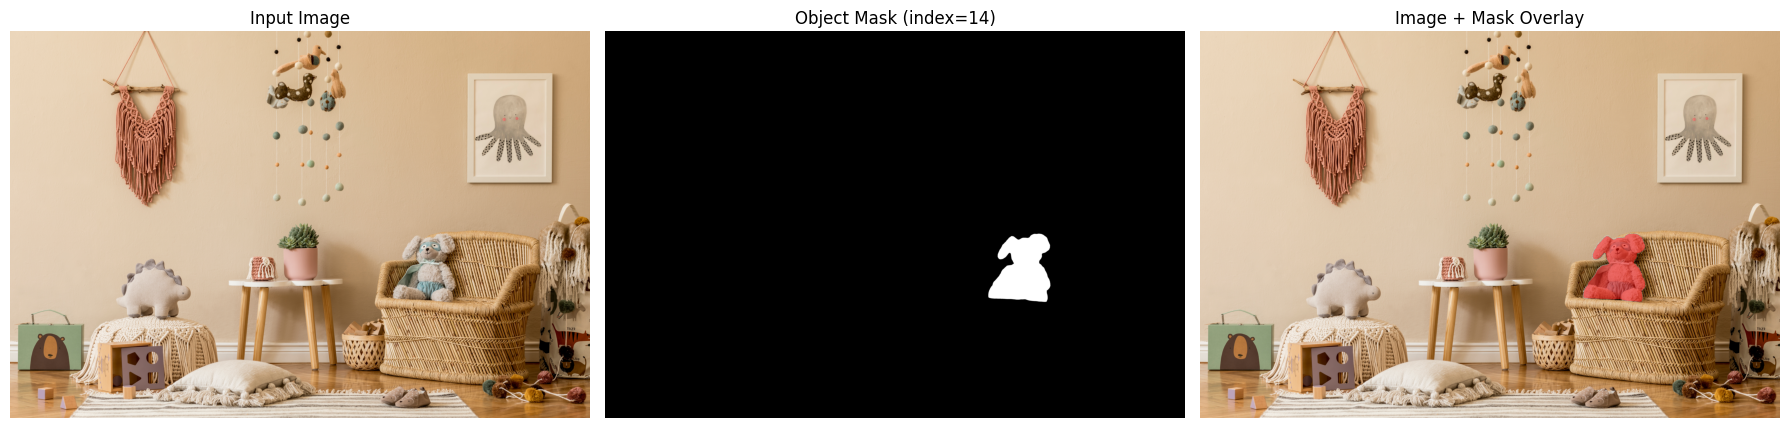

In [16]:
import matplotlib.pyplot as plt
from PIL import Image

# Load image + mask using the SAME functions as demo_single_object.ipynb
from inference import load_image, load_single_mask

IMAGE_FOLDER = SAM3D_NOTEBOOK / "images" / "shutterstock_stylish_kidsroom_1640806567"
IMAGE_PATH = str(IMAGE_FOLDER / "image.png")
IMAGE_NAME = os.path.basename(str(IMAGE_FOLDER))
MASK_INDEX = 14

# Aligned with demo_single_object.ipynb:
#   image = load_image(IMAGE_PATH)
#   mask = load_single_mask(os.path.dirname(IMAGE_PATH), index=14)
image = load_image(IMAGE_PATH)
mask = load_single_mask(str(IMAGE_FOLDER), index=MASK_INDEX)

print(f"Image shape: {image.shape}, dtype: {image.dtype}")
print(f"Mask shape:  {mask.shape}, dtype: {mask.dtype}")
print(f"Mask coverage: {mask.sum() / mask.size * 100:.1f}%")

# Display image + mask overlay
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(image[..., :3])
axes[0].set_title("Input Image")
axes[0].axis("off")
axes[1].imshow(mask, cmap="gray")
axes[1].set_title(f"Object Mask (index={MASK_INDEX})")
axes[1].axis("off")
overlay = image[..., :3].copy()
mask_rgba = np.zeros((*mask.shape, 4), dtype=np.uint8)
mask_rgba[mask] = [255, 0, 0, 128]
axes[2].imshow(overlay)
axes[2].imshow(mask_rgba)
axes[2].set_title("Image + Mask Overlay")
axes[2].axis("off")
plt.tight_layout()
plt.show()

In [17]:
# Run model — aligned with demo_single_object.ipynb:
#   output = inference(image, mask, seed=42)
# The OV pipeline's __call__ has the same signature as the original Inference class.
print("Running OpenVINO pipeline (aligned with demo_single_object.ipynb API) …")
t0 = time.time()

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    single_output = ov_pipeline(image, mask, seed=42)

elapsed = time.time() - t0
print(f"\nPipeline completed in {elapsed:.1f}s")
print(f"Output keys: {list(single_output.keys())}")

# Export gaussian splat — aligned with demo_single_object.ipynb:
#   output["gs"].save_ply(f"{PATH}/gaussians/single/{IMAGE_NAME}.ply")
if "gs" in single_output and single_output["gs"] is not None:
    gs = single_output["gs"]
    ply_path = NOTEBOOK_DIR / "gaussians" / "single" / f"{IMAGE_NAME}.ply"
    ply_path.parent.mkdir(parents=True, exist_ok=True)
    gs.save_ply(str(ply_path))
    n_points = gs._xyz.shape[0] if hasattr(gs, "_xyz") else "unknown"
    print(f"Gaussian Splat: {n_points:,} points → {ply_path}")

# Inspect Mesh output
if "glb" in single_output and single_output["glb"] is not None:
    glb = single_output["glb"]
    glb_path = NOTEBOOK_DIR / "single_object.glb"
    glb.export(str(glb_path))
    print(f"Mesh: {len(glb.vertices):,} vertices, {len(glb.faces):,} faces → {glb_path}")
else:
    print("No mesh output (mesh decoder may not be available)")

Running OpenVINO pipeline (aligned with demo_single_object.ipynb API) …


2026-03-23 18:18:56.566 | INFO     | sam3d_objects.pipeline.inference_pipeline:sample_sparse_structure:664 - Sampling sparse structure: inference_steps=25, strength=7, interval=[0, 500], rescale_t=3, cfg_strength_pm=0.0
2026-03-23 18:18:56.567 | INFO     | sam3d_objects.pipeline.inference_pipeline:get_condition_input:633 - Running condition embedder ...
2026-03-23 18:18:59.524 | INFO     | sam3d_objects.pipeline.inference_pipeline:get_condition_input:637 - Condition embedder finishes!
2026-03-23 18:22:47.529 | INFO     | sam3d_objects.pipeline.inference_pipeline:sample_sparse_structure:714 - Downsampled coords from 23323 to 23043
2026-03-23 18:22:47.535 | INFO     | sam3d_objects.pipeline.inference_pipeline_pointmap:run:437 - Rescaling scale by 1 after downsampling
2026-03-23 18:22:47.536 | INFO     | sam3d_objects.pipeline.inference_pipeline:sample_slat:744 - Sampling sparse latent: inference_steps=25, strength=1, interval=[0, 500], rescale_t=1
2026-03-23 18:22:47.536 | INFO     | sam


  OV-SAM3D Benchmark — Per-Model Latency Statistics
  Model                                         Calls  Total(s)   Avg(ms)   Min(ms)   Max(ms)
----------------------------------------------------------------------
  OVDinoEmbedder(condition_embedders.slat_condition_embedder.embedder_list[0][0])     2     1.065    532.73    504.99    560.47
  OVDinoEmbedder(condition_embedders.slat_condition_embedder.embedder_list[1][0])     2     1.035    517.37    454.61    580.14
  OVDinoEmbedder(condition_embedders.ss_condition_embedder.embedder_list[0][0])     2     1.084    542.25    464.44    620.05
  OVDinoEmbedder(condition_embedders.ss_condition_embedder.embedder_list[1][0])     2     1.076    537.90    533.96    541.84
  OVEmbedderProjection(condition_embedders.slat_condition_embedder.projection_nets.0)     2     0.062     31.24      9.64     52.85
  OVEmbedderProjection(condition_embedders.slat_condition_embedder.projection_nets.1)     2     0.073     36.59      9.23     63.94
  OVEmbedd

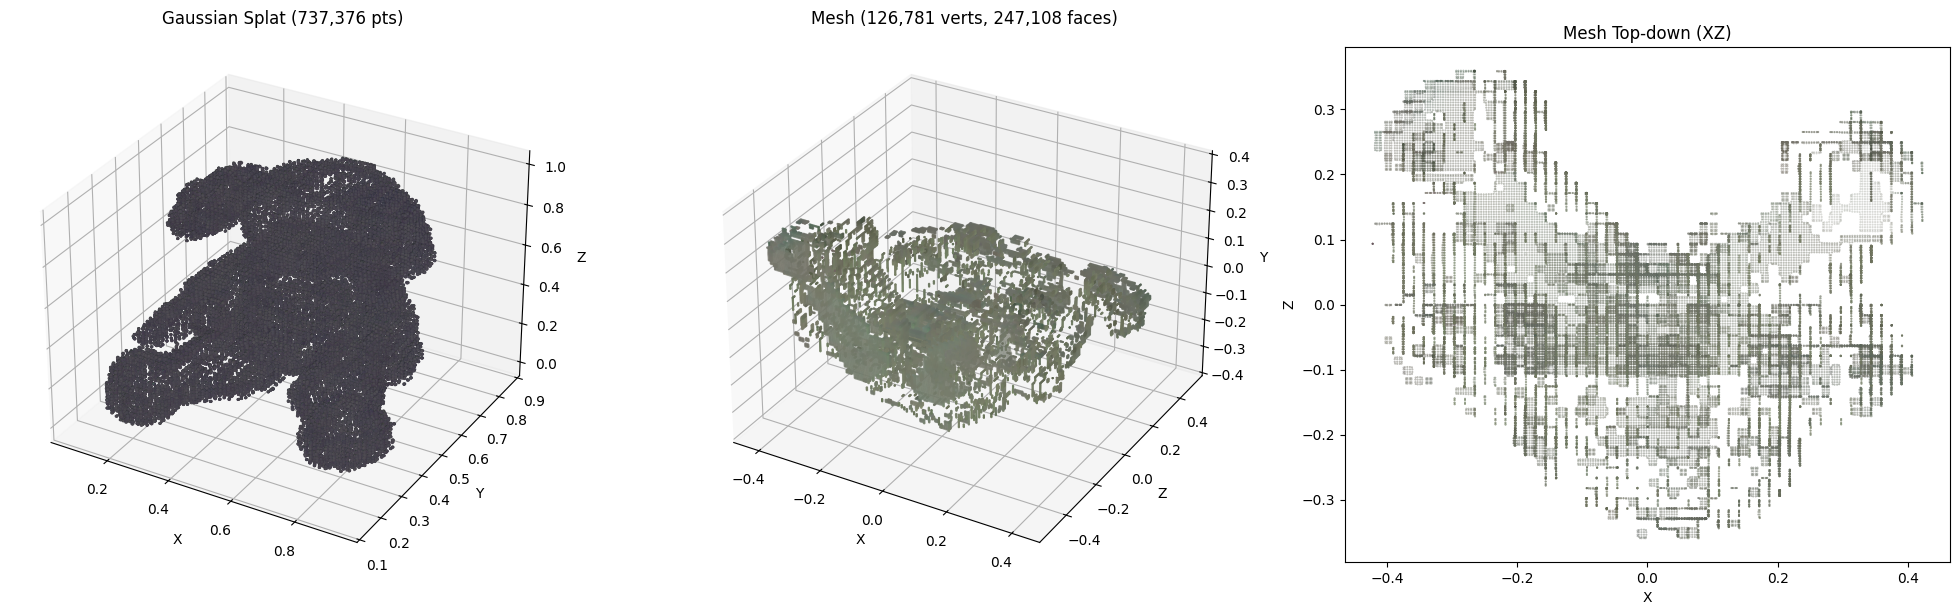

In [18]:
# Visualize the single-object outputs: Gaussian Splat + Mesh
fig = plt.figure(figsize=(20, 6))

# --- Gaussian Splat ---
if "gs" in single_output and single_output["gs"] is not None:
    gs = single_output["gs"]
    xyz = gs._xyz.detach().cpu().numpy()
    if hasattr(gs, "_features_dc") and gs._features_dc is not None:
        colors = gs._features_dc.detach().cpu().numpy().squeeze()
        colors = (colors - colors.min()) / (colors.max() - colors.min() + 1e-8)
        point_colors = colors[:, :3] if colors.ndim == 2 and colors.shape[1] >= 3 else xyz[:, 1]
    else:
        point_colors = xyz[:, 1]

    ax1 = fig.add_subplot(131, projection="3d")
    ax1.scatter(xyz[:, 0], xyz[:, 1], xyz[:, 2], c=point_colors, s=0.5, alpha=0.4)
    ax1.set_xlabel("X"); ax1.set_ylabel("Y"); ax1.set_zlabel("Z")
    ax1.set_title(f"Gaussian Splat ({len(xyz):,} pts)")

# --- Mesh ---
if "glb" in single_output and single_output["glb"] is not None:
    glb = single_output["glb"]
    verts = glb.vertices
    faces = glb.faces

    # Get vertex colors
    if hasattr(glb.visual, "vertex_colors") and glb.visual.vertex_colors is not None:
        vc = glb.visual.vertex_colors[:, :3].astype(np.float32) / 255.0
    else:
        vc = "steelblue"

    ax2 = fig.add_subplot(132, projection="3d")
    ax2.scatter(verts[:, 0], verts[:, 1], verts[:, 2], c=vc, s=0.3, alpha=0.4)
    ax2.set_xlabel("X"); ax2.set_ylabel("Z"); ax2.set_zlabel("Y")
    ax2.set_title(f"Mesh ({len(verts):,} verts, {len(faces):,} faces)")

    ax3 = fig.add_subplot(133)
    ax3.scatter(verts[:, 0], verts[:, 2], s=0.2, alpha=0.3, c=vc if isinstance(vc, np.ndarray) else "steelblue")
    ax3.set_xlabel("X"); ax3.set_ylabel("Z")
    ax3.set_title("Mesh Top-down (XZ)")
    ax3.set_aspect("equal")

plt.tight_layout()
plt.show()

## Multi Object 3D Reconstruction
[back to top ⬆️](#Table-of-contents:)

Following the original [`demo_multi_object.ipynb`](https://github.com/facebookresearch/sam-3d-objects/blob/main/notebook/demo_multi_object.ipynb), we load **multiple** object masks from the same scene and run the OpenVINO pipeline for each object independently.

This demonstrates the ability to reconstruct an entire scene by lifting multiple objects to 3D, matching the multi-object workflow of the original pipeline.

Found 27 object masks
Using 2 masks for multi-object demo


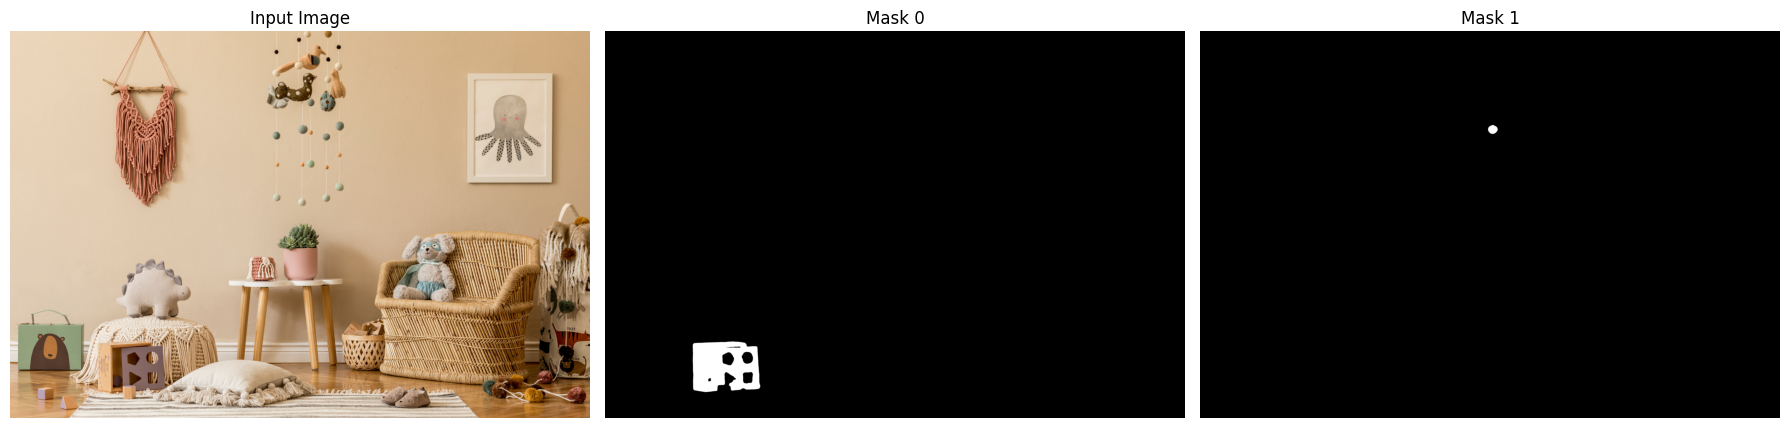

In [19]:
# Load all available masks — aligned with demo_multi_object.ipynb:
#   masks = load_masks(folder, extension=".png")
from inference import load_masks

all_masks = load_masks(str(IMAGE_FOLDER))
print(f"Found {len(all_masks)} object masks")

# For demo speed, limit to a small subset of masks
MAX_OBJECTS = 2
selected_masks = all_masks[:MAX_OBJECTS]
print(f"Using {len(selected_masks)} masks for multi-object demo")

# Display selected masks
fig, axes = plt.subplots(1, len(selected_masks) + 1, figsize=(6 * (len(selected_masks) + 1), 5))
axes[0].imshow(image[..., :3])
axes[0].set_title("Input Image")
axes[0].axis("off")
for i, m in enumerate(selected_masks):
    axes[i + 1].imshow(m, cmap="gray")
    axes[i + 1].set_title(f"Mask {i}")
    axes[i + 1].axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# Run OpenVINO pipeline for each object mask
# Using the same __call__ API as demo_single_object: output = inference(image, mask, seed=42)
multi_outputs = []
print(f"Running OpenVINO pipeline for {len(selected_masks)} objects …\n")

for i, obj_mask in enumerate(selected_masks):
    print(f"  Object {i}: mask coverage {obj_mask.sum() / obj_mask.size * 100:.1f}%")
    t0 = time.time()

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        out = ov_pipeline(image, obj_mask, seed=42)

    elapsed = time.time() - t0
    multi_outputs.append(out)

    n_pts = out["gs"]._xyz.shape[0] if "gs" in out and out["gs"] is not None else 0
    n_verts = len(out["glb"].vertices) if "glb" in out and out["glb"] is not None else 0
    print(f"    → {n_pts:,} Gaussian pts, {n_verts:,} mesh verts in {elapsed:.1f}s")

    # Save each object's GLB
    if "glb" in out and out["glb"] is not None:
        glb_path = NOTEBOOK_DIR / f"multi_object_{i}.glb"
        out["glb"].export(str(glb_path))
        print(f"    → Saved GLB → {glb_path}")

print(f"\nAll {len(multi_outputs)} objects processed.")

In [ ]:
# Visualize multi-object results — each object displayed separately
for i, out in enumerate(multi_outputs):
    fig = plt.figure(figsize=(20, 6))
    fig.suptitle(f"Object {i}", fontsize=14, fontweight="bold")

    # --- Gaussian Splat ---
    if "gs" in out and out["gs"] is not None:
        xyz = out["gs"]._xyz.detach().cpu().numpy()
        if hasattr(out["gs"], "_features_dc") and out["gs"]._features_dc is not None:
            colors = out["gs"]._features_dc.detach().cpu().numpy().squeeze()
            colors = (colors - colors.min()) / (colors.max() - colors.min() + 1e-8)
            pc = colors[:, :3] if colors.ndim == 2 and colors.shape[1] >= 3 else xyz[:, 1]
        else:
            pc = xyz[:, 1]

        ax1 = fig.add_subplot(131, projection="3d")
        ax1.scatter(xyz[:, 0], xyz[:, 1], xyz[:, 2], c=pc, s=0.5, alpha=0.4)
        ax1.set_xlabel("X"); ax1.set_ylabel("Y"); ax1.set_zlabel("Z")
        ax1.set_title(f"Gaussian Splat ({len(xyz):,} pts)")

    # --- Mesh (vertex-colored) ---
    if "glb" in out and out["glb"] is not None:
        glb = out["glb"]
        verts = glb.vertices
        faces = glb.faces
        if hasattr(glb.visual, "vertex_colors") and glb.visual.vertex_colors is not None:
            vc = glb.visual.vertex_colors[:, :3].astype(np.float32) / 255.0
        else:
            vc = "steelblue"

        ax2 = fig.add_subplot(132, projection="3d")
        ax2.scatter(verts[:, 0], verts[:, 1], verts[:, 2], c=vc, s=0.3, alpha=0.4)
        ax2.set_xlabel("X"); ax2.set_ylabel("Z"); ax2.set_zlabel("Y")
        ax2.set_title(f"Mesh ({len(verts):,} verts, {len(faces):,} faces)")

        ax3 = fig.add_subplot(133)
        ax3.scatter(verts[:, 0], verts[:, 2], s=0.2, alpha=0.3,
                    c=vc if isinstance(vc, np.ndarray) else "steelblue")
        ax3.set_xlabel("X"); ax3.set_ylabel("Z")
        ax3.set_title("Mesh Top-down (XZ)")
        ax3.set_aspect("equal")

    plt.tight_layout()
    plt.show()

## Optimize with NNCF Quantization
[back to top ⬆️](#Table-of-contents:)

[NNCF](https://github.com/openvinotoolkit/nncf) provides a suite of advanced algorithms for Neural Network inference optimization in OpenVINO with minimal accuracy drop.

The DINOv2 image encoders are the most computationally expensive components in the SAM-3D-Objects pipeline. We use 8-bit post-training quantization to optimize the **SS DINOv2 image encoder**, which encodes the input image for sparse structure generation.

The optimization process:
1. Create a calibration dataset from COCO128 images
2. Run `nncf.quantize` with Transformer-specific settings
3. Save the quantized INT8 model
4. Validate by comparing FP32 and INT8 outputs

In [ ]:
from notebook_utils import quantization_widget

to_quantize = quantization_widget(False)
to_quantize

In [ ]:
# Fetch skip_kernel_extension for %%skip magic
skip_kernel_extension_file_name = "skip_kernel_extension.py"

if not Path(skip_kernel_extension_file_name).exists():
    r = requests.get(
        url=f"https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/{skip_kernel_extension_file_name}",
    )
    open(skip_kernel_extension_file_name, "w").write(r.text)

%load_ext skip_kernel_extension

### Prepare Calibration Dataset
[back to top ⬆️](#Table-of-contents:)

Download COCO128 images for calibration. Since we only need representative input data to calibrate the quantization parameters, we don't need annotations.

In [ ]:
%%skip not $to_quantize.value

from zipfile import ZipFile
from notebook_utils import download_file

DATA_URL = "https://ultralytics.com/assets/coco128.zip"
OUT_DIR = Path(".")

if not (OUT_DIR / "coco128/images/train2017").exists():
    download_file(DATA_URL, directory=OUT_DIR, show_progress=True)
    with ZipFile("coco128.zip", "r") as zip_ref:
        zip_ref.extractall(OUT_DIR)

In [ ]:
%%skip not $to_quantize.value

import cv2
import nncf
import torch.utils.data as data


class COCOLoader(data.Dataset):
    """Simple COCO image loader for quantization calibration."""

    def __init__(self, images_path):
        self.images = sorted(Path(images_path).glob("*.jpg"))

    def __getitem__(self, index):
        image = cv2.imread(str(self.images[index]))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        # Resize to DINOv2 expected input size and normalize to [0, 1]
        image = cv2.resize(image, (518, 518))
        image = image.astype(np.float32) / 255.0
        # Convert HWC → CHW
        image = np.transpose(image, (2, 0, 1))
        return image

    def __len__(self):
        return len(self.images)


coco_dataset = COCOLoader(OUT_DIR / "coco128/images/train2017")
calibration_loader = data.DataLoader(coco_dataset, batch_size=1, shuffle=False)


def transform_fn(image_data):
    """Extract preprocessed image tensor for quantization calibration."""
    return image_data.numpy()


calibration_dataset = nncf.Dataset(calibration_loader, transform_fn)
print(f"Calibration dataset: {len(coco_dataset)} images")

### Run Quantization
[back to top ⬆️](#Table-of-contents:)

Quantize the SS DINOv2 image encoder using `nncf.quantize` with Transformer-specific settings. This uses a mixed quantization preset (symmetric weights, asymmetric activations) for better accuracy preservation.

> **Note**: Quantization is a time-consuming process. Be patient, it can take several minutes depending on your hardware.

In [ ]:
%%skip not $to_quantize.value

ss_dino_image_int8_path = OV_MODEL_DIR / "ss_dino_image_int8.xml"

if not ss_dino_image_int8_path.exists():
    print("Quantizing SS DINOv2 image encoder …")
    t0 = time.time()

    fp32_model = core.read_model(str(OV_MODEL_DIR / "ss_dino_image.xml"))
    quantized_model = nncf.quantize(
        fp32_model,
        calibration_dataset,
        model_type=nncf.parameters.ModelType.TRANSFORMER,
        subset_size=128,
    )

    ov.save_model(quantized_model, str(ss_dino_image_int8_path))
    elapsed = time.time() - t0
    print(f"Quantization completed in {elapsed:.1f}s")
    print(f"Saved INT8 model → {ss_dino_image_int8_path}")

    # Compare file sizes
    fp32_size = (OV_MODEL_DIR / "ss_dino_image.bin").stat().st_size / (1024 * 1024)
    int8_size = ss_dino_image_int8_path.with_suffix(".bin").stat().st_size / (1024 * 1024)
    print(f"FP32 size: {fp32_size:.1f} MB → INT8 size: {int8_size:.1f} MB ({int8_size / fp32_size * 100:.0f}%)")
else:
    print(f"INT8 model already exists: {ss_dino_image_int8_path}")

### Validate Quantized Model
[back to top ⬆️](#Table-of-contents:)

Compare FP32 and INT8 model outputs to verify the quantized model maintains acceptable accuracy.

In [ ]:
%%skip not $to_quantize.value

# Compare FP32 vs INT8 outputs
test_img = torch.randn(1, 3, 518, 518, dtype=torch.float32)

# FP32 inference
fp32_compiled = core.compile_model(core.read_model(str(OV_MODEL_DIR / "ss_dino_image.xml")), device.value)
fp32_out = torch.from_numpy(fp32_compiled(test_img.numpy())[0].copy())

# INT8 inference
int8_compiled = core.compile_model(core.read_model(str(ss_dino_image_int8_path)), device.value)
int8_out = torch.from_numpy(int8_compiled(test_img.numpy())[0].copy())

# Compare
print("=" * 60)
print("FP32 vs INT8 Comparison (SS DINOv2 Image Encoder)")
print("=" * 60)
max_diff = (fp32_out - int8_out).abs().max().item()
mean_diff = (fp32_out - int8_out).abs().mean().item()
cos_sim = torch.nn.functional.cosine_similarity(
    fp32_out.flatten().unsqueeze(0),
    int8_out.flatten().unsqueeze(0),
).item()

print(f"  Max absolute diff:  {max_diff:.6f}")
print(f"  Mean absolute diff: {mean_diff:.6f}")
print(f"  Cosine similarity:  {cos_sim:.6f}")
print(f"  Status: {'PASS ✓' if cos_sim > 0.99 else 'WARNING — low similarity'}")

## Interactive Gradio Demo
[back to top ⬆️](#Table-of-contents:)

Launch an interactive Gradio demo that allows you to:
- Select an object mask from the demo scene
- Adjust the number of inference steps (fewer steps = faster but lower quality)
- Run the full two-stage 3D reconstruction pipeline
- View the resulting 3D Gaussian Splat visualization

> **Note**: Each reconstruction takes approximately 60–120 seconds on CPU, depending on hardware.

In [ ]:
from gradio_helper import make_demo

demo = make_demo(
    ov_pipeline=ov_pipeline,
    image_folder=IMAGE_FOLDER,
    helper=helper,
    stage1_steps=2,
    stage2_steps=2,
)

# Launch the Gradio demo (non-blocking in notebook mode)
try:
    demo.launch(debug=False, height=800)
except Exception as e:
    print(f"Gradio launch note: {e}")
    print("Run this cell interactively to use the Gradio demo.")